# AI Powered Road Damage Detection

## Data Preparation and Preprocessing

Imports

In [1]:
import os
import cv2
import glob
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import albumentations as A

Dataset Paths

In [2]:
DATASET_PATH = "India/train"

IMAGE_PATH = os.path.join(DATASET_PATH, "images")
ANNOTATION_PATH = os.path.join(DATASET_PATH, "annotations/xmls")

print("Images:", len(os.listdir(IMAGE_PATH)))
print("Annotations:", len(os.listdir(ANNOTATION_PATH)))

Images: 7706
Annotations: 7706


### EDA

Inspect Sample Images

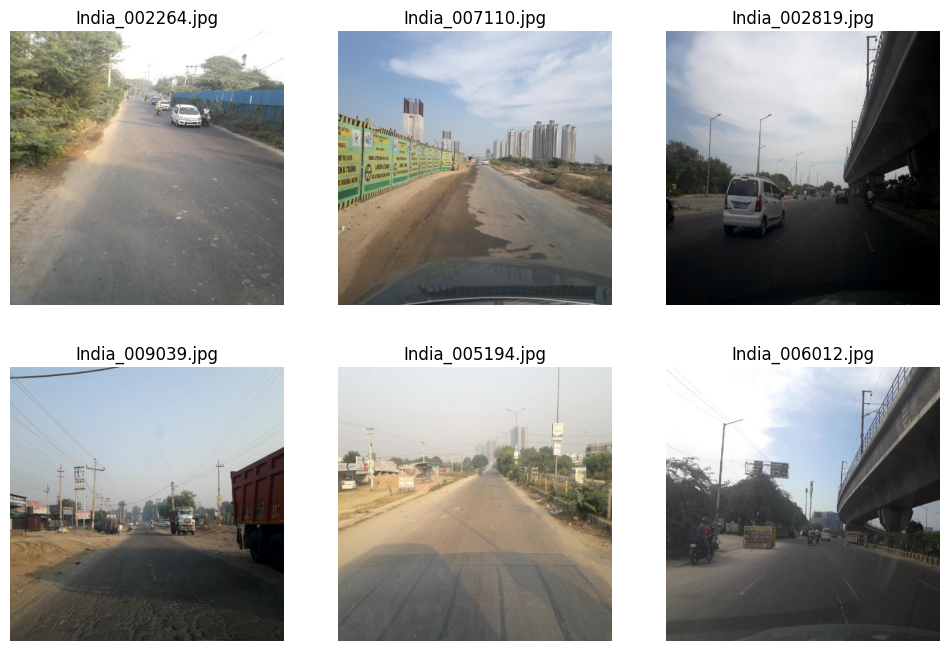

In [3]:
sample_images = random.sample(os.listdir(IMAGE_PATH), 6)

plt.figure(figsize=(12,8))

for i,img_name in enumerate(sample_images):
    
    img = cv2.imread(os.path.join(IMAGE_PATH,img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

Image Resolution Analysis

In [4]:
image_files = glob.glob(IMAGE_PATH+"/*.jpg")
annotation_files = glob.glob(ANNOTATION_PATH+"/*.xml")

widths=[]
heights=[]

for img_path in image_files[:1000]:

    img=cv2.imread(img_path)

    h,w,_=img.shape

    widths.append(w)
    heights.append(h)

print("Average Width:",np.mean(widths))
print("Average Height:",np.mean(heights))

Average Width: 720.0
Average Height: 720.0


Parse XML Annotations

In [5]:
def parse_annotation(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        
        label = obj.find("name").text
        
        bbox = obj.find("bndbox")
        
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        boxes.append([label, xmin, ymin, xmax, ymax])

    return boxes

Class Distribution

In [6]:
class_counts={
"D00":0,
"D10":0,
"D20":0,
"D40":0
}

for xml_file in tqdm(annotation_files):

    boxes=parse_annotation(xml_file)

    for b in boxes:

        label=b[0]

        if label in class_counts:
            class_counts[label]+=1

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count}")

100%|██████████| 7706/7706 [00:28<00:00, 270.37it/s] 

Class Distribution:
D00: 1555
D10: 68
D20: 2021
D40: 3187


Visualization of class distribution

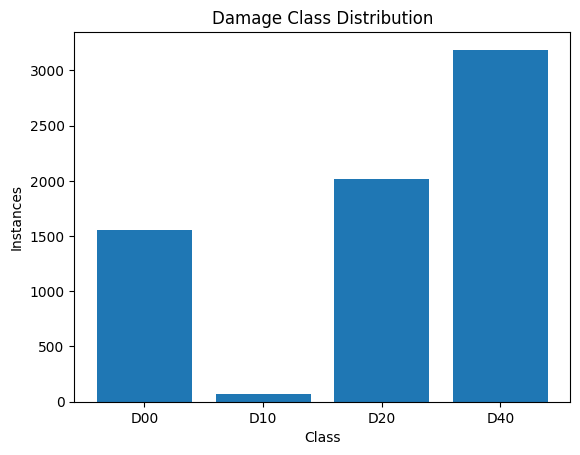

In [7]:
plt.bar(class_counts.keys(),class_counts.values())

plt.title("Damage Class Distribution")
plt.xlabel("Class")
plt.ylabel("Instances")

plt.show()

Bounding Box Size Distribution

In [8]:
areas=[]

for xml_file in annotation_files:

    boxes=parse_annotation(xml_file)

    for b in boxes:

        xmin,ymin,xmax,ymax=b[1:]

        area=(xmax-xmin)*(ymax-ymin)

        areas.append(area)

print("Average Area:",np.mean(areas))
print("Median Area:",np.median(areas))
print("Max Area:",np.max(areas))
print("Min Area:",np.min(areas))
print("Area Std Dev:",np.std(areas))

Average Area: 24218.12166280629
Median Area: 9856.0
Max Area: 346368
Min Area: 304
Area Std Dev: 33473.03338694723


Visualization of bounding box distribution

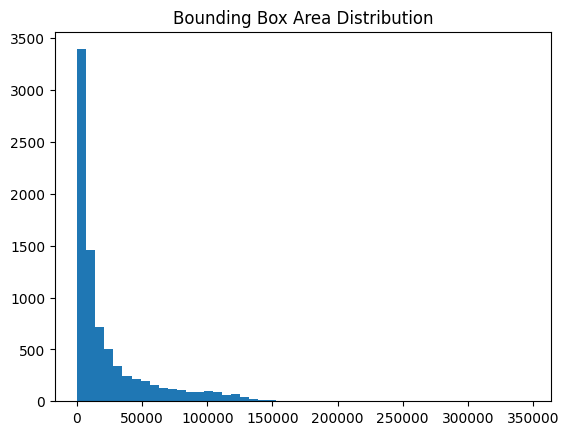

In [9]:
plt.hist(areas,bins=50)

plt.title("Bounding Box Area Distribution")

plt.show()

### Data Preparation

Filter Required Classes

In [10]:
VALID_CLASSES = [
    "D00",  # longitudinal crack
    "D10",  # transverse crack
    "D40"   # pothole
]

def filter_boxes(boxes):

    filtered = []

    for b in boxes:
        if b[0] in VALID_CLASSES:
            filtered.append(b)

    return filtered

Convert Annotations to YOLO Format

In [11]:
CLASS_MAP = {
    "D00":0,
    "D10":1,
    "D40":2
}

def convert_to_yolo(box, img_w, img_h):

    label,xmin,ymin,xmax,ymax = box

    x_center = ((xmin + xmax)/2)/img_w
    y_center = ((ymin + ymax)/2)/img_h
    width = (xmax - xmin)/img_w
    height = (ymax - ymin)/img_h

    return CLASS_MAP[label],x_center,y_center,width,height

Create YOLO Label Files

In [12]:
YOLO_LABEL_DIR = "content/yolo_labels"

os.makedirs(YOLO_LABEL_DIR,exist_ok=True)

for xml_file in tqdm(glob.glob(ANNOTATION_PATH+"/*.xml")):

    boxes = parse_annotation(xml_file)
    boxes = filter_boxes(boxes)

    img_file = xml_file.replace(".xml",".jpg").replace("annotations/xmls","images")
    
    img = cv2.imread(img_file)
    
    if img is None:
        continue
        
    h,w,_ = img.shape

    label_path = os.path.join(YOLO_LABEL_DIR,
                              os.path.basename(xml_file).replace(".xml",".txt"))

    with open(label_path,"w") as f:
        
        for box in boxes:
            
            cls,x,y,bw,bh = convert_to_yolo(box,w,h)
            
            f.write(f"{cls} {x} {y} {bw} {bh}\n")

100%|██████████| 7706/7706 [01:14<00:00, 103.18it/s]


Resize Images

In [ ]:
RESIZED_DIR = "content/resized_images"
os.makedirs(RESIZED_DIR,exist_ok=True)

for img_file in tqdm(os.listdir(IMAGE_PATH)):

    img = cv2.imread(os.path.join(IMAGE_PATH,img_file))

    img = cv2.resize(img,(640,640))

    cv2.imwrite(os.path.join(RESIZED_DIR,img_file),img)

100%|██████████| 7706/7706 [00:58<00:00, 131.04it/s]


Data Augmentation

In [14]:
transform = A.Compose([
    
    A.HorizontalFlip(p=0.5),
    
    A.RandomBrightnessContrast(p=0.3),
    
    A.MotionBlur(p=0.2),
    
    A.GaussNoise(p=0.2),
    
])

def augment_image(img):

    augmented = transform(image=img)

    return augmented["image"]

Train / Validation Split

In [15]:
images = os.listdir(RESIZED_DIR)

random.shuffle(images)

split = int(0.8 * len(images))

train_images = images[:split]
val_images = images[split:]

print("Train:",len(train_images))
print("Validation:",len(val_images))

Train: 6164
Validation: 1542


Create Final Dataset Structure

In [16]:
def create_dirs():

    for folder in [
        "dataset/images/train",
        "dataset/images/val",
        "dataset/labels/train",
        "dataset/labels/val"
    ]:
        os.makedirs(folder,exist_ok=True)

create_dirs()

Move Files to Train / Validation

In [17]:
for img in train_images:

    shutil.copy(os.path.join(RESIZED_DIR,img),
                "dataset/images/train/"+img)

    label = img.replace(".jpg",".txt")

    shutil.copy(os.path.join(YOLO_LABEL_DIR,label),
                "dataset/labels/train/"+label)

In [18]:
for img in val_images:

    shutil.copy(os.path.join(RESIZED_DIR,img),
                "dataset/images/val/"+img)

    label = img.replace(".jpg",".txt")

    shutil.copy(os.path.join(YOLO_LABEL_DIR,label),
                "dataset/labels/val/"+label)

Final Dataset Summary

In [19]:
print("Training Images:",len(os.listdir("dataset/images/train")))
print("Validation Images:",len(os.listdir("dataset/images/val")))

Training Images: 6164
Validation Images: 1542


Visualization of Labels

In [20]:
def visualize(img_path,label_path):

    img = cv2.imread(img_path)
    h,w,_ = img.shape

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls,x,y,bw,bh = map(float,line.split())

        xmin = int((x - bw/2) * w)
        ymin = int((y - bh/2) * h)
        xmax = int((x + bw/2) * w)
        ymax = int((y + bh/2) * h)

        cv2.rectangle(img,(xmin,ymin),(xmax,ymax),(0,255,0),2)

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.axis("off")

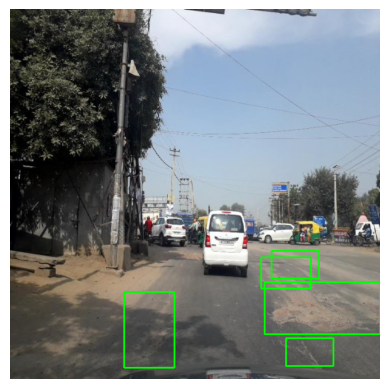

In [21]:
visualize('dataset/images/train/India_000057.jpg', 'dataset/labels/train/India_000057.txt')
plt.axis("off")
plt.show()
